<a href="https://colab.research.google.com/github/AhmdMt/Training/blob/main/First_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

dl = pd.read_csv('/content/sample_data.csv')

dl = dl.dropna(subset=['Guarantor Name'])

columns_to_drop = ['#', 'Date', 'Day', 'Adress']
dl = dl.drop(columns=[col for col in columns_to_drop if col in dl.columns])

X = dl.drop('Laboratory', axis=1)
y = dl['Laboratory']

# تحويل المتغيرات النصية إلى أرقام (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# تقسيم البيانات مع الحفاظ على التوازن (Stratified Split)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#  التنبؤ وتقييم الأداء بالثلاثة مقاييس

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== نتائج تقييم النموذج النهائي ===")
print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('F1 Score :', round(f1_score(y_test, y_pred, average='weighted'), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_pred_proba), 4))

joblib.dump(model, 'logistic_model.pkl')
joblib.dump(X.columns, 'model_columns.pkl')

print("\nبنجاح (logistic_model.pkl) والنموذج (model_columns.pkl  تم حفظ أسماء الأعمدة !")


=== نتائج تقييم النموذج النهائي ===
Accuracy : 0.9419
F1 Score : 0.9138
ROC-AUC  : 0.6349

بنجاح (logistic_model.pkl) والنموذج (model_columns.pkl  تم حفظ أسماء الأعمدة !


In [3]:
!pip install arabic-reshaper python-bidi
import arabic_reshaper
import matplotlib.pyplot as plt
import seaborn as sns

from bidi.algorithm import get_display

def ar(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 5.6 MB/s eta 0:00:00


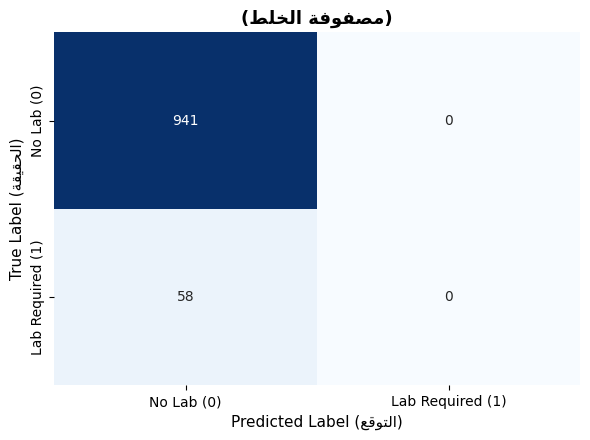

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# حساب مصفوفة الخلط
cm = confusion_matrix(y_test, y_pred)

#  رسم المصفوفة
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Lab (0)', 'Lab Required (1)'],
            yticklabels=['No Lab (0)', 'Lab Required (1)'])

plt.title(ar('(مصفوفة الخلط)'), fontsize=13, fontweight='bold')
plt.xlabel(ar('Predicted Label (التوقع)'), fontsize=11)
plt.ylabel(ar('True Label (الحقيقة)'), fontsize=11)

plt.tight_layout()
plt.show()


NameError: name 'fpr' is not defined

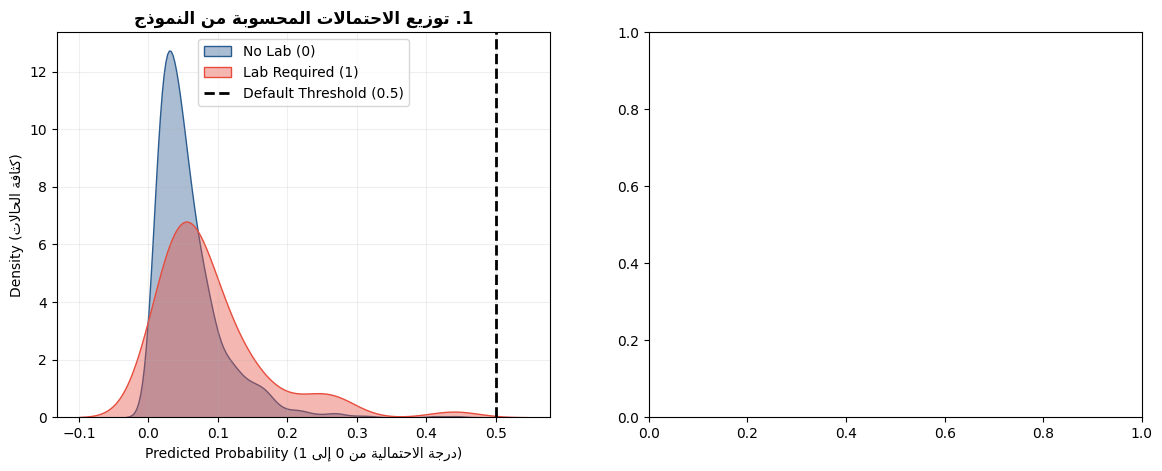

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# إعداد مساحة الرسم (رسمين متجاورين)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# الرسم الأول: توزيع الاحتمالات التي يتوقعها النموذج لكل فئة

sns.kdeplot(y_pred_proba[y_test == 0], ax=axes[0], color='#2b5c8f', label='No Lab (0)', fill=True, alpha=0.4)
sns.kdeplot(y_pred_proba[y_test == 1], ax=axes[0], color='#e74c3c', label='Lab Required (1)', fill=True, alpha=0.4)

# رسم خط الحد الافتراضي (0.5)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

axes[0].set_title(ar('1. توزيع الاحتمالات المحسوبة من النموذج'), fontsize=12, fontweight='bold')
axes[0].set_xlabel(ar('Predicted Probability (درجة الاحتمالية من 0 إلى 1)'))
axes[0].set_ylabel(ar('Density (كثافة الحالات)'))
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# الرسم الثاني: منحنى ROC الناتج عن تحريك حد الفصل

pr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_val = roc_auc_score(y_test, y_pred_proba)

axes[1].plot(fpr, tpr, color='#27ae60', lw=3, label=f'ROC Curve (AUC = {auc_val:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (0.50)')

axes[1].set_title(ar('2. منحنى ROC (ربط نسبة الاكتشاف بالإنذارات الخاطئة)'), fontsize=12, fontweight='bold')
axes[1].set_xlabel(ar('False Positive Rate (نسبة التنبؤات الخاطئة)'))
axes[1].set_ylabel(ar('True Positive Rate (نسبة الاكتشاف الصحيح)'))
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:

!pip install gradio -q

import gradio as gr
import pandas as pd
import joblib

model = joblib.load('logistic_model.pkl')
model_columns = joblib.load('model_columns.pkl')

def predict_patient(age, gender, guarantor):
    # تجهيز البيانات في DataFrame
    input_data = pd.DataFrame([{
        'Age': age,
        'Gender': gender,
        'Guarantor Name': guarantor
    }])


    input_encoded = pd.get_dummies(input_data)


    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)


    prediction = model.predict(input_encoded)[0]
    probability = model.predict_proba(input_encoded)[0][1] * 100

    if prediction == 1:
        return f"مُوصى بالاستهداف (محتمل يطلب تحليل بنسبة {probability:.1f}%)"
    else:
        return f"غير مستهدف حالياً (احتمالية الطلب منخفضة: {probability:.1f}%)"

#تصميم واجهة المستخدم
demo = gr.Interface(
    fn=predict_patient,
    inputs=[
        gr.Number(label="العمر (Age)", value=60),
        gr.Dropdown(choices=["Male", "Female"], label="الجنس (Gender)", value="Male"),
        gr.Textbox(label="الكفيل / شركة التأمين (Guarantor Name)", value="Payer_011")
    ],
    outputs=gr.Textbox(label="نتيجة التنبؤ والتوصية"),
    title="🏥 نظام التنبؤ بطلب التحاليل الروتينية",
    description="أدخل بيانات المراجع لمعرفة هل هو ضمن أعلى 20% المستهدفين للتواصل"
)

# تشغيل الواجهة
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25928de2db3e1086e1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
!pip install gradio pandas openpyxl -q

import gradio as gr
import pandas as pd
import joblib

# تحميل النموذج وأسماء الأعمدة المحفوظة
model = joblib.load('logistic_model.pkl')
model_columns = joblib.load('model_columns.pkl')

# دالة معالجة الملف الكامل
def process_patient_file(file_obj):

    if file_obj.name.endswith('.csv'):
        df = pd.read_csv(file_obj.name)
    else:
        df = pd.read_excel(file_obj.name)

    # احتفاظ بنسخة من البيانات الأصلية لإضافة التوصيات عليها
    results_df = df.copy()

    #  تجهيز الأعمدة للنموذج (One-Hot Encoding)
    df_encoded = pd.get_dummies(df[['Age', 'Gender', 'Guarantor Name']])
    df_encoded = df_encoded.reindex(columns=model_columns, fill_value=0)

    #  حساب نسبة احتمالية طلب التحليل لكل مراجع
    probabilities = model.predict_proba(df_encoded)[:, 1] * 100
    results_df['احتمالية_الطلب_%'] = probabilities.round(1)

    #  ترتيب المرضى من الأعلى احتمالية إلى الأقل
    results_df = results_df.sort_values(by='احتمالية_الطلب_%', ascending=False)

    # تحديد أعلى 20% كهدف رئيسي للتواصل
    cutoff_index = int(len(results_df) * 0.20)
    results_df['الحالة'] = '⚪ غير مستهدف'
    results_df.iloc[:cutoff_index, results_df.columns.get_loc('الحالة')] = '🎯 مستهدف (أعلى 20%)'

    # تصدير الناتج لملف Excel جاهز للتحميل
    output_path = "مرشحو_الحملة_التسويقية.xlsx"
    results_df.to_excel(output_path, index=False)

    return output_path

# تصميم واجهة رفع وتحميل الملفات
demo = gr.Interface(
    fn=process_patient_file,
    inputs=gr.File(label="📁 ارفع ملف المرضى (Excel أو CSV)"),
    outputs=gr.File(label="📥 تحميل الملف المعالج والمصنف تلقائياً"),
    title="🏥 أداة المعالجة الجماعية للتنبؤ بطلب التحاليل الطبية",
    description="ارفع ملف المراجعين، وسيتم فرزهم وتحديد أعلى 20% الأكثر احتمالية لطلب التحاليل وتصديرهم بملف Excel."
)

# تشغيل الواجهة وإنشاء رابط خارجي
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e3550997253e276b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
